In [ ]:
# XGBoost y SHAP normalmente ya vienen en Colab, pero forzamos versión reciente
!pip install -q xgboost shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier
import shap

# Semilla para que los resultados sean reproducibles
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

resultado_ventas = glob.glob('/content/drive/MyDrive/**/ventas.csv', recursive=False)
resultado_detalle = glob.glob('/content/drive/MyDrive/**/detalle-ventas.csv', recursive=False)

print("ventas.csv encontrado en:", resultado_ventas)
print("detalle-ventas.csv encontrado en:", resultado_detalle)

ruta_ventas = resultado_ventas[0]
ruta_detalle = resultado_detalle[0]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ventas.csv encontrado en: ['/content/drive/MyDrive/dataset/ventas.csv']
detalle-ventas.csv encontrado en: ['/content/drive/MyDrive/dataset/detalle-ventas.csv']


### Carga de datos

In [ ]:
def cargar_ventas(path):
    """Carga el archivo de cabecera de ventas (una fila por venta)."""
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig')

    # format='mixed' detecta el formato de cada fecha automáticamente (hay filas con y sin hora)
    fecha_completa = pd.to_datetime(df['Fecha'], format='mixed', errors='coerce')
    df['Fecha'] = fecha_completa.dt.normalize()  # se queda solo con el día, la hora se descarta
    return df

def cargar_detalle_ventas(path):
    """Carga el detalle de productos por venta (varias filas por venta).
    Nota: la primera fila del CSV es basura (';;;;...') por eso usamos skiprows=1,
    y luego eliminamos columnas 'Unnamed' que sobran al final."""
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig', skiprows=1)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    fecha_completa = pd.to_datetime(df['Fecha'], format='mixed', errors='coerce')
    df['Fecha'] = fecha_completa.dt.normalize()  # solo día, sin hora
    return df

ventas = cargar_ventas(ruta_ventas)
detalle = cargar_detalle_ventas(ruta_detalle)

# Diagnóstico: si alguna fecha no se pudo interpretar, aparece como NaT (vacío)
print("Fechas no reconocidas en ventas:", ventas['Fecha'].isna().sum())
print("Fechas no reconocidas en detalle:", detalle['Fecha'].isna().sum())

print("\nVentas:", ventas.shape)
print("Detalle de ventas:", detalle.shape)
ventas.head()

Fechas no reconocidas en ventas: 0
Fechas no reconocidas en detalle: 0

Ventas: (939, 5)
Detalle de ventas: (1240, 9)


,ID,Fecha,Metodo_Pago,ID_Cliente,Total
0,VTA-0000001,2026-03-15,YAPE,1,9.4
1,VTA-0000002,2026-03-15,EFECTIVO,1,1.2
2,VTA-0000003,2026-03-15,EFECTIVO,1,10.0
3,VTA-0000004,2026-03-15,EFECTIVO,1,19.6
4,VTA-0000005,2026-03-16,YAPE,1,1.8


## Ingeniería de características (feature engineering)

`Metodo_Pago` (lo que queremos predecir) está a nivel de **venta completa** (un ticket),
pero el tipo de producto está a nivel de **detalle** (cada línea del ticket). Por eso,
primero resumimos `detalle-ventas.csv` a una fila por venta, y luego lo unimos con
`ventas.csv`.

Variables que construimos:
- **Total**: monto de la venta.
- **departamento_principal / pct_fotocopiadora**: qué tipo de producto predomina en la venta.
- **n_items / n_productos_distintos**: tamaño de la compra.
- **dia_semana / es_fin_de_semana**: patrón temporal (sin usar la hora).

**Importante — fuga de datos:** `detalle-ventas.csv` tiene una columna `Medio` que es
idéntica a `Metodo_Pago`. La excluimos a propósito: si la usáramos, el modelo "adivinaría"
el pago con 100% de precisión sin haber aprendido nada real, porque sería la respuesta
disfrazada de pregunta.

In [ ]:
def construir_features_detalle(detalle):
    """Resume la información de productos de detalle-ventas.csv a una fila por venta."""
    agg = detalle.groupby('ID_Venta').agg(
        n_items=('Cantidad', 'sum'),
        n_productos_distintos=('ID_Producto', 'nunique'),
        departamento_principal=('Departamento', lambda x: x.mode().iloc[0]),
        pct_fotocopiadora=('Departamento', lambda x: (x == 'FOTOCOPIADORA').mean())
        # 'Medio' se descarta a propósito: es idéntico a Metodo_Pago (fuga de datos)
    ).reset_index()
    return agg

def construir_dataset_modelo(ventas, detalle):
    """Une ventas.csv (Metodo_Pago, Total, Fecha) con el resumen de detalle-ventas.csv."""
    feats_detalle = construir_features_detalle(detalle)
    df = ventas.merge(feats_detalle, left_on='ID', right_on='ID_Venta', how='inner')

    df['dia_semana'] = df['Fecha'].dt.dayofweek  # 0=Lunes ... 6=Domingo
    df['es_fin_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    # Variable objetivo: 1 = YAPE, 0 = EFECTIVO
    df['target'] = df['Metodo_Pago'].map({'YAPE': 1, 'EFECTIVO': 0})

    columnas_finales = [
        'ID', 'Total', 'n_items', 'n_productos_distintos',
        'departamento_principal', 'pct_fotocopiadora',
        'dia_semana', 'es_fin_de_semana', 'target'
    ]
    return df[columnas_finales]

dataset = construir_dataset_modelo(ventas, detalle)
print("Filas y columnas del dataset final:", dataset.shape)
print("\nDistribución del método de pago:")
print(dataset['target'].value_counts(normalize=True).rename({0: 'EFECTIVO', 1: 'YAPE'}))
dataset.head()

Filas y columnas del dataset final: (939, 9)

Distribución del método de pago:
target
EFECTIVO    0.674121
YAPE        0.325879
Name: proportion, dtype: float64


,ID,Total,n_items,n_productos_distintos,departamento_principal,pct_fotocopiadora,dia_semana,es_fin_de_semana,target
0,VTA-0000001,9.4,5,2,FOTOCOPIADORA,0.5,6,1,1
1,VTA-0000002,1.2,1,0,UTILES,0.0,6,1,0
2,VTA-0000003,10.0,17,2,FOTOCOPIADORA,1.0,6,1,0
3,VTA-0000004,19.6,245,1,FOTOCOPIADORA,1.0,6,1,0
4,VTA-0000005,1.8,3,1,UTILES,0.0,0,0,1


## Análisis exploratorio (EDA) de las variables predictoras

Aquí no repetimos el EDA general del proyecto (eso lo cubre el Panel 1). Solo revisamos,
de forma simple, **si nuestras 3 variables clave (monto, tipo de producto, patrón de día)
realmente se ven distintas entre quienes pagan con YAPE y quienes pagan en EFECTIVO**.
Si se ven parecidas entre ambos grupos, es una señal de que al modelo le costará más
distinguirlos.

/tmp/ipykernel_572/3812437580.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['EFECTIVO', 'YAPE'])
/tmp/ipykernel_572/3812437580.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Entre semana', 'Fin de semana'])


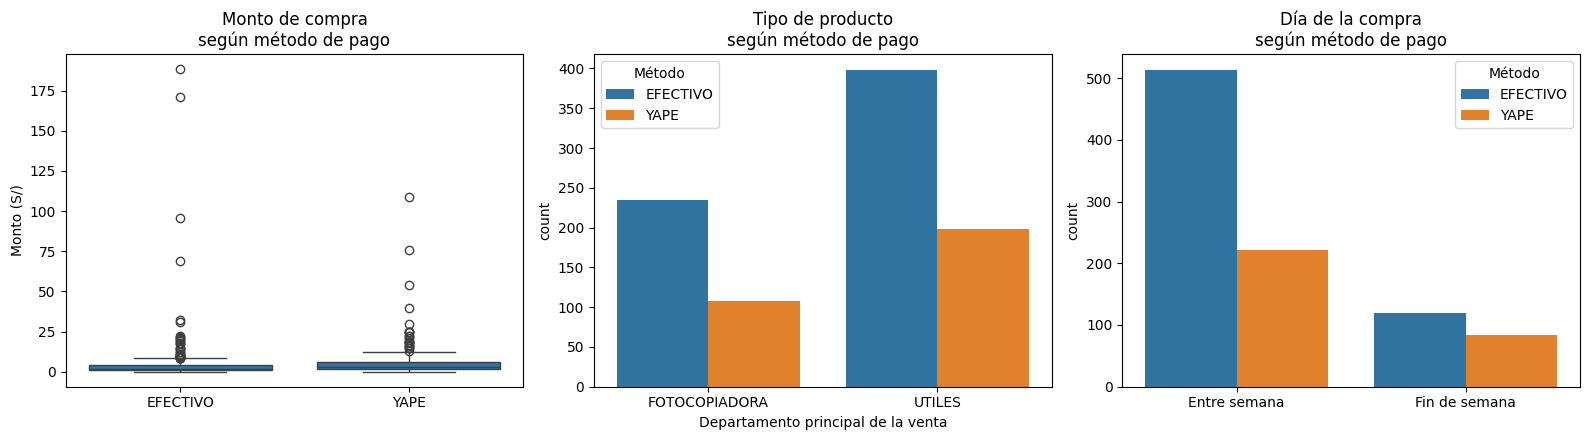

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Gráfico 1: ¿el monto de la compra es distinto según el método de pago?
sns.boxplot(data=dataset, x='target', y='Total', ax=axes[0])
axes[0].set_xticklabels(['EFECTIVO', 'YAPE'])
axes[0].set_title('Monto de compra\nsegún método de pago')
axes[0].set_xlabel('')
axes[0].set_ylabel('Monto (S/)')

# Gráfico 2: ¿el tipo de producto influye en el método de pago?
sns.countplot(data=dataset, x='departamento_principal', hue='target', ax=axes[1])
axes[1].set_title('Tipo de producto\nsegún método de pago')
axes[1].set_xlabel('Departamento principal de la venta')
axes[1].legend(title='Método', labels=['EFECTIVO', 'YAPE'])

# Gráfico 3: ¿el día de la semana influye en el método de pago?
sns.countplot(data=dataset, x='es_fin_de_semana', hue='target', ax=axes[2])
axes[2].set_xticklabels(['Entre semana', 'Fin de semana'])
axes[2].set_title('Día de la compra\nsegún método de pago')
axes[2].set_xlabel('')
axes[2].legend(title='Método', labels=['EFECTIVO', 'YAPE'])

plt.tight_layout()
plt.show()

## Preparación final: codificar y separar en entrenamiento / prueba

Los modelos de Machine Learning solo entienden números, así que convertimos
`departamento_principal` (texto: "UTILES" / "FOTOCOPIADORA") en un número con
`LabelEncoder`.

Luego separamos los datos en:
- **80% entrenamiento**: para que el modelo aprenda los patrones.
- **20% prueba**: datos que el modelo nunca vio, para evaluarlo de forma justa.

Usamos `stratify=y` para que ambos grupos mantengan la misma proporción de
YAPE/EFECTIVO que el dataset original (evita que, por azar, el set de prueba
quede con casi puro EFECTIVO o casi puro YAPE).

In [ ]:
def preparar_datos(dataset, test_size=0.2):
    """Codifica variables categóricas y separa en train/test."""
    df = dataset.copy()

    le_depto = LabelEncoder()
    df['departamento_principal_enc'] = le_depto.fit_transform(df['departamento_principal'])

    X = df[['Total', 'n_items', 'n_productos_distintos',
            'departamento_principal_enc', 'pct_fotocopiadora',
            'dia_semana', 'es_fin_de_semana']]
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    return X_train, X_test, y_train, y_test, le_depto

X_train, X_test, y_train, y_test, le_depto = preparar_datos(dataset)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (751, 7)  Test: (188, 7)


## Entrenamiento y evaluación de los modelos

Entrenamos dos modelos y comparamos su desempeño:
- **Random Forest**: varios árboles de decisión "votando" juntos.
- **XGBoost**: árboles que se corrigen uno al otro de forma secuencial.

Para cada uno medimos:
- **Accuracy**: % total de aciertos.
- **Precision / Recall / F1**: qué tan bien detecta específicamente los pagos con YAPE.
- **ROC-AUC**: qué tan bien separa ambas clases en general.
- **Matriz de confusión**: cuántos aciertos y errores hubo, y de qué tipo.

Como hay más ventas en EFECTIVO que en YAPE (~66% vs ~34%), usamos balanceo de clases
(`class_weight='balanced'` y `scale_pos_weight`) para que el modelo no ignore la clase
minoritaria (YAPE).

In [ ]:
def entrenar_y_evaluar(modelo, nombre, X_train, y_train, X_test, y_test):
    """Entrena un modelo, calcula métricas y grafica su matriz de confusión."""
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, y_pred, target_names=['EFECTIVO', 'YAPE']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['EFECTIVO', 'YAPE'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()

    return modelo, metricas

### Modelo 1 aplicado: Random Forest


--- Random Forest ---
              precision    recall  f1-score   support

    EFECTIVO       0.71      0.72      0.72       127
        YAPE       0.40      0.38      0.39        61

    accuracy                           0.61       188
   macro avg       0.55      0.55      0.55       188
weighted avg       0.61      0.61      0.61       188



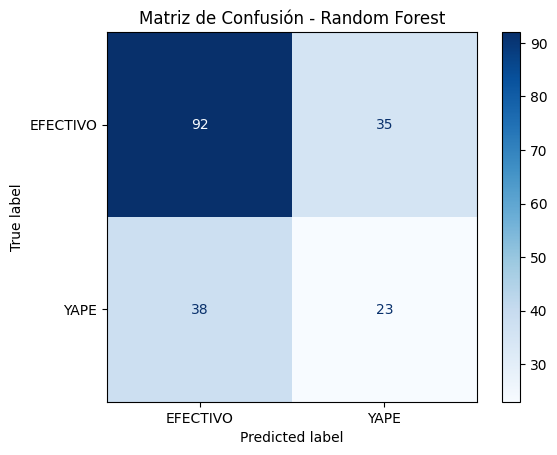

In [ ]:
rf_modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',   # compensa el desbalance (66% Efectivo / 34% Yape)
    random_state=RANDOM_STATE
)

rf_modelo, rf_metricas = entrenar_y_evaluar(
    rf_modelo, "Random Forest", X_train, y_train, X_test, y_test
)

### Modelo 2 aplicado: XG Boost


--- XGBoost ---
              precision    recall  f1-score   support

    EFECTIVO       0.71      0.66      0.68       127
        YAPE       0.38      0.43      0.40        61

    accuracy                           0.59       188
   macro avg       0.54      0.54      0.54       188
weighted avg       0.60      0.59      0.59       188



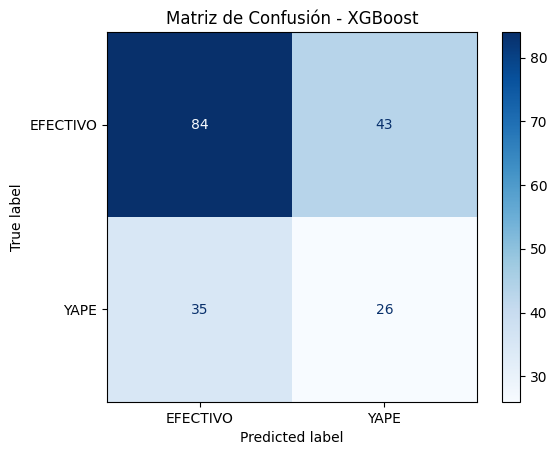

In [ ]:
peso_balance = (y_train == 0).sum() / (y_train == 1).sum()

xgb_modelo = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=peso_balance,  # compensa el desbalance de clases
    eval_metric='logloss',
    random_state=RANDOM_STATE
)

xgb_modelo, xgb_metricas = entrenar_y_evaluar(
    xgb_modelo, "XGBoost", X_train, y_train, X_test, y_test
)

### Comparación de ambos modelos

               accuracy  precision  recall     f1  roc_auc
modelo                                                    
Random Forest     0.612      0.397   0.377  0.387    0.582
XGBoost           0.585      0.377   0.426  0.400    0.555


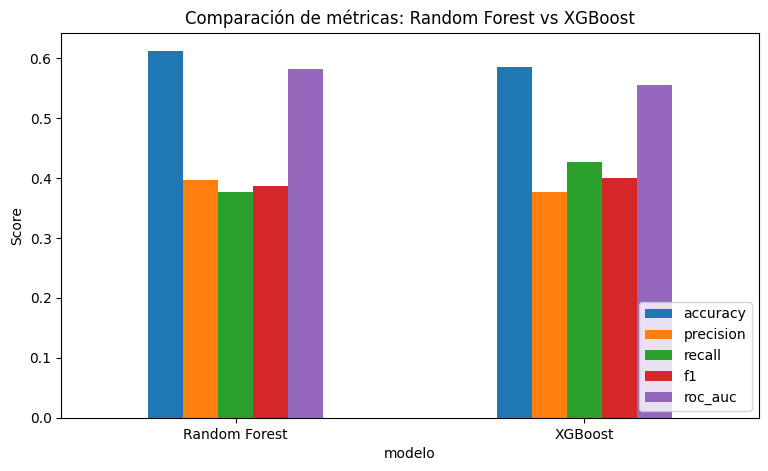

In [ ]:
comparacion = pd.DataFrame([rf_metricas, xgb_metricas]).set_index('modelo')
print(comparacion.round(3))

comparacion.plot(kind='bar', figsize=(9, 5))
plt.title('Comparación de métricas: Random Forest vs XGBoost')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

### Interpretabilidad con SHAP

Modelo elegido para SHAP: XGBoost


/tmp/ipykernel_572/1238909776.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap_clase1, X_test, plot_type="bar", show=False)


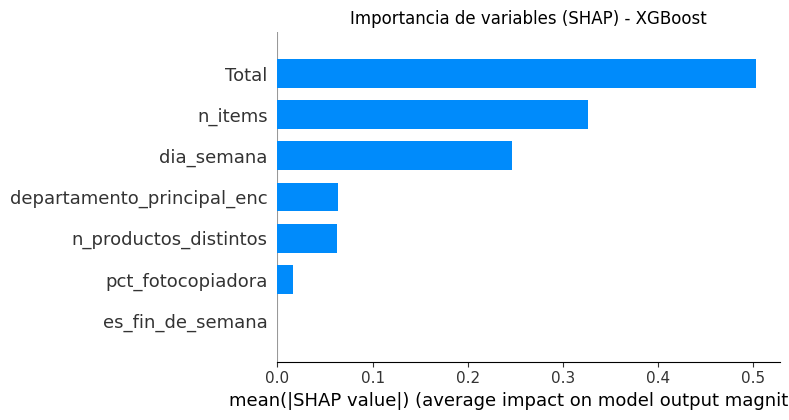

/tmp/ipykernel_572/1238909776.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(valores_shap_clase1, X_test, show=False)


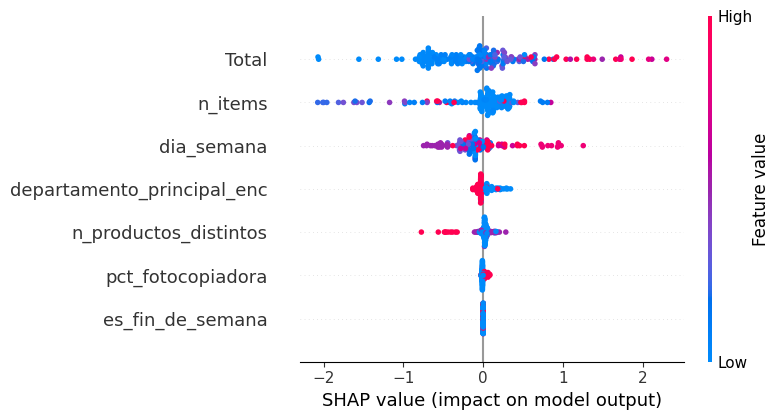

In [ ]:
mejor_modelo, nombre_mejor = (
    (xgb_modelo, "XGBoost") if xgb_metricas['f1'] >= rf_metricas['f1']
    else (rf_modelo, "Random Forest")
)
print(f"Modelo elegido para SHAP: {nombre_mejor}")

explainer = shap.TreeExplainer(mejor_modelo)
shap_values = explainer.shap_values(X_test)

# Random Forest devuelve una lista [clase0, clase1]; XGBoost devuelve un solo array
valores_shap_clase1 = shap_values[1] if isinstance(shap_values, list) else shap_values

# Qué variables más influyen en predecir YAPE (de mayor a menor peso)
shap.summary_plot(valores_shap_clase1, X_test, plot_type="bar", show=False)
plt.title(f'Importancia de variables (SHAP) - {nombre_mejor}')
plt.tight_layout()
plt.show()

# Cómo influye cada variable: dirección (rojo=alto, azul=bajo) y magnitud
shap.summary_plot(valores_shap_clase1, X_test, show=False)
plt.tight_layout()
plt.show()

### Guardado del modelo

In [ ]:
import pickle

ruta_guardado = "/content/drive/MyDrive/" + ruta_ventas.split("MyDrive/")[1].rsplit("/", 1)[0] + "/modelo_metodo_pago.pkl"

with open(ruta_guardado, 'wb') as f:
    pickle.dump({
        'modelo': mejor_modelo,
        'label_encoder_departamento': le_depto,
        'columnas': list(X_train.columns)
    }, f)

print("Modelo guardado en:", ruta_guardado)

Modelo guardado en: /content/drive/MyDrive/dataset/modelo_metodo_pago.pkl


## Apartado Extra (predicción ventas estimadas por día, YAPE vs Efectivo)

## Plus: Ventas estimadas por día, según método de pago

Además de predecir el método de pago de una venta puntual, agregamos una estimación
a nivel de negocio: **¿cuánto se espera vender en YAPE y cuánto en EFECTIVO en un día
cualquiera, según qué día de la semana sea?**


In [ ]:
def construir_ventas_diarias(ventas):
    """
    Convierte el detalle de ventas individuales en un resumen por día:
    cuánto se vendió en EFECTIVO y cuánto en YAPE cada día que hubo actividad.
    """
    diario = (
        ventas
        .groupby([ventas['Fecha'], 'Metodo_Pago'])['Total']
        .sum()
        .unstack(fill_value=0)   # una columna por método de pago, 0 si no hubo ventas de ese tipo ese día
        .reset_index()
    )
    diario['dia_semana'] = diario['Fecha'].dt.dayofweek       # 0=Lunes ... 6=Domingo
    diario['es_fin_de_semana'] = diario['dia_semana'].isin([5, 6]).astype(int)
    return diario

ventas_diarias = construir_ventas_diarias(ventas)
print("Días distintos con ventas registradas:", len(ventas_diarias))
ventas_diarias.head()

Días distintos con ventas registradas: 87


Metodo_Pago,Fecha,EFECTIVO,YAPE,dia_semana,es_fin_de_semana
0,2026-01-04,24.4,13.7,6,1
1,2026-01-05,0.0,93.4,0,0
2,2026-03-15,30.8,9.4,6,1
3,2026-03-16,18.0,12.3,0,0
4,2026-03-17,53.3,7.6,1,0


## ¿Cómo estimamos las ventas por día?

Calculamos, para cada día de la semana (Lunes, Martes, ..., Domingo), el **promedio
histórico** de ventas en EFECTIVO y en YAPE. Esto nos da una estimación de "un día
típico de esa semana", que sirve como pronóstico para planificar.

También reportamos cuántas observaciones históricas respaldan cada promedio — un
promedio calculado con 16 días es más confiable que uno calculado con solo 6.

In [ ]:
# Calculo del promedio por dia por semana
def estimar_ventas_por_dia_semana(ventas_diarias):
    """Calcula el promedio histórico de ventas por método de pago, para cada día de la semana."""
    resumen = ventas_diarias.groupby('dia_semana').agg(
        EFECTIVO_estimado=('EFECTIVO', 'mean'),
        YAPE_estimado=('YAPE', 'mean'),
        n_dias_observados=('EFECTIVO', 'size')
    ).round(2)

    nombres_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    resumen.index = nombres_dias
    return resumen

estimacion_semanal = estimar_ventas_por_dia_semana(ventas_diarias)
print("Ventas estimadas por día de la semana (S/):\n")
print(estimacion_semanal)

Ventas estimadas por día de la semana (S/):

           EFECTIVO_estimado  YAPE_estimado  n_dias_observados
Lunes                  22.05          30.88                 15
Martes                 24.32          12.58                 17
Miércoles              38.87          11.98                 13
Jueves                 33.79          21.15                 12
Viernes                18.17          10.10                 14
Sábado                 43.02          31.47                  6
Domingo                36.41          27.87                 10


### Visualización ventas estimadas YAPE vs EFECTIVO

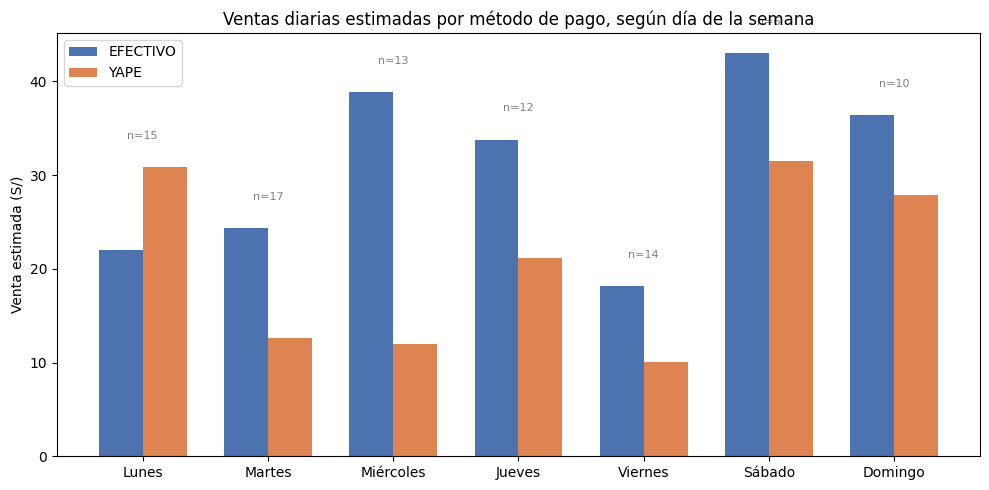

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(estimacion_semanal))
ancho = 0.35

ax.bar(x - ancho/2, estimacion_semanal['EFECTIVO_estimado'], ancho, label='EFECTIVO', color='#4C72B0')
ax.bar(x + ancho/2, estimacion_semanal['YAPE_estimado'], ancho, label='YAPE', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(estimacion_semanal.index)
ax.set_ylabel('Venta estimada (S/)')
ax.set_title('Ventas diarias estimadas por método de pago, según día de la semana')
ax.legend()

# Anotar cuántos días respaldan cada barra
for i, n in enumerate(estimacion_semanal['n_dias_observados']):
    ax.text(i, max(estimacion_semanal.iloc[i, :2]) + 3, f'n={n}', ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## Función de consulta: "¿cuánto se espera vender tal día?"

Por último, armamos una función simple para consultar la estimación dado un día de la
semana o una fecha futura concreta (a partir de la cual se obtiene el día de la semana
correspondiente).

In [ ]:
def predecir_venta_diaria(dia_o_fecha, estimacion_semanal):
    """
    Devuelve la venta estimada en EFECTIVO y YAPE para un día dado.
    Acepta: nombre del día ('Martes'), o una fecha ('2026-08-05').
    """
    if dia_o_fecha in estimacion_semanal.index:
        nombre_dia = dia_o_fecha
    else:
        fecha = pd.to_datetime(dia_o_fecha)
        nombre_dia = estimacion_semanal.index[fecha.dayofweek]

    fila = estimacion_semanal.loc[nombre_dia]
    print(f"Estimación para un {nombre_dia} (basada en {int(fila['n_dias_observados'])} días históricos):")
    print(f"  EFECTIVO: S/ {fila['EFECTIVO_estimado']:.2f}")
    print(f"  YAPE:     S/ {fila['YAPE_estimado']:.2f}")
    print(f"  TOTAL:    S/ {fila['EFECTIVO_estimado'] + fila['YAPE_estimado']:.2f}")

    return fila['EFECTIVO_estimado'], fila['YAPE_estimado']

# Ejemplos de uso:
predecir_venta_diaria('Sábado', estimacion_semanal)
print()
predecir_venta_diaria('2026-08-12', estimacion_semanal)  # cualquier fecha futura

Estimación para un Sábado (basada en 6 días históricos):
  EFECTIVO: S/ 43.02
  YAPE:     S/ 31.47
  TOTAL:    S/ 74.49

Estimación para un Miércoles (basada en 13 días históricos):
  EFECTIVO: S/ 38.87
  YAPE:     S/ 11.98
  TOTAL:    S/ 50.85


(np.float64(38.87), np.float64(11.98))